# Pipeline de Segmentação Semântica e Extração de Instâncias com U-Net ResNet18

Este notebook apresenta o fluxo completo da pipeline de segmentação semântica e extração de instâncias pelo **Método Ingênuo (Limiar + Componentes Conexos)**, estruturado em duas etapas principais:
1. **Parte 0 — Teste Unitário Sintético**: Geração e validação rápida em um dataset sintético de elipses.
2. **Parte 1 — Dados Reais (DSB2018 / )**: Carregamento, fusão de máscaras de núcleos e avaliação em imagens reais de microscopia.

> **Estrutura de Código**: As funções auxiliares, arquitetura do modelo, data loaders, treino, métricas e algoritmo de componentes conexos estão modularizados em  para manter o notebook limpo e focado no fluxo de execução.


In [1]:
# Auto-reload e importação do módulo utils
%load_ext autoreload
%autoreload 2

import importlib
import utils
importlib.reload(utils)

device = utils.get_device()
print(f"Dispositivo selecionado para execução: {device}")


Dispositivo selecionado para execução: cuda


In [2]:
# 2. Inicialização da Arquitetura do Modelo U-Net com Backbone ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)

# Teste de Sanidade do Formato de Saída (Batch dummy de tamanho 2x3x128x128)
import torch
dummy_in = torch.randn(2, 3, 128, 128, device=device)
dummy_out = model_test(dummy_in)
print(f"Arquitetura carregada. Dimensão do tensor de saída: {tuple(dummy_out.shape)}")


Arquitetura carregada. Dimensão do tensor de saída: (2, 1, 128, 128)


## Parte 0 — Teste Unitário com Dataset Sintético
Nesta etapa, geramos 100 imagens sintéticas contendo elipses sobrepostas e dividimos os dados em **Treino (70%)**, **Validação (15%)** e **Teste (15%)**.


In [3]:
# 3. Geração do Dataset Sintético de Elipses e Divisão dos Dados (X_train, X_val, X_test)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=100, image_size=(128, 128), seed=42)

X_train_synth, y_train_synth, X_val_synth, y_val_synth, X_test_synth, y_test_synth = utils.split_dataset(
    images_synth, masks_synth, train_ratio=0.70, val_ratio=0.15, seed=42
)

print(f"[Sintético] Conjunto de Treino:   X={X_train_synth.shape}, y={y_train_synth.shape}")
print(f"[Sintético] Conjunto de Validação: X={X_val_synth.shape}, y={y_val_synth.shape}")
print(f"[Sintético] Conjunto de Teste:     X={X_test_synth.shape}, y={y_test_synth.shape}")


[Sintético] Conjunto de Treino:   X=(70, 128, 128, 3), y=(70, 128, 128)
[Sintético] Conjunto de Validação: X=(15, 128, 128, 3), y=(15, 128, 128)
[Sintético] Conjunto de Teste:     X=(15, 128, 128, 3), y=(15, 128, 128)


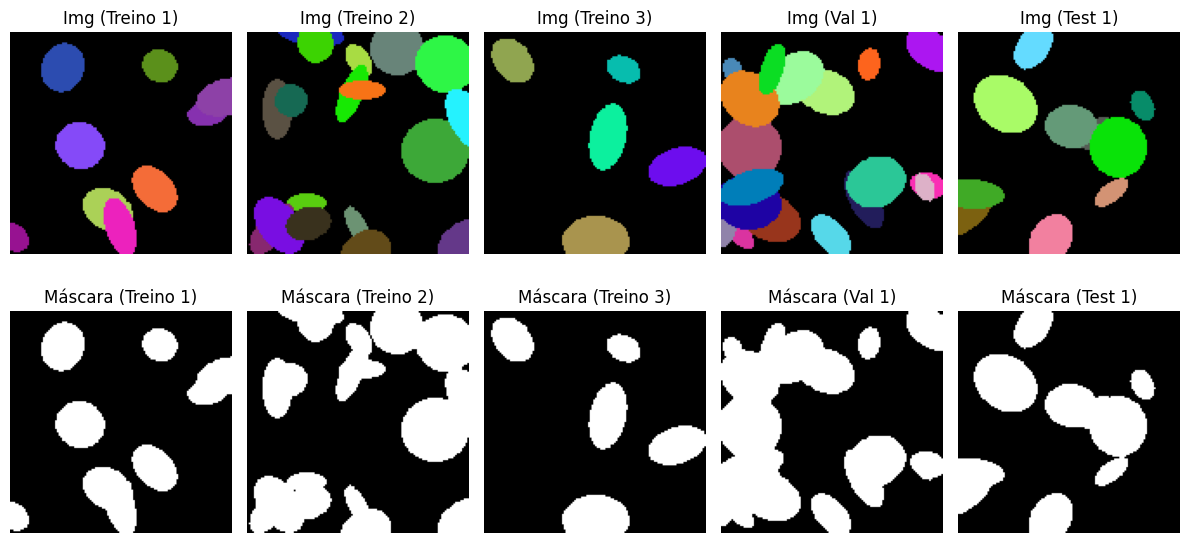

In [4]:
# 4. Visualização de Amostras do Dataset Sintético
utils.plot_dataset_samples(X_train_synth, y_train_synth, X_val_synth, y_val_synth, X_test_synth, y_test_synth)


In [5]:
# 5. Treinamento da U-Net no Dataset Sintético
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
print("=== Treinamento no Dataset Sintético ===")
utils.train_model(
    model=model_synth,
    X_train=X_train_synth,
    y_train=y_train_synth,
    X_val=X_val_synth,
    y_val=y_val_synth,
    device=device,
    num_epochs=10,
    batch_size=8,
    learning_rate=0.001
)


=== Treinamento no Dataset Sintético ===
Epoch [ 1/10] | Train Loss: 0.4057 | Val Loss: 0.5939
Epoch [ 2/10] | Train Loss: 0.2548 | Val Loss: 0.3474
Epoch [ 3/10] | Train Loss: 0.2103 | Val Loss: 0.2514
Epoch [ 4/10] | Train Loss: 0.1764 | Val Loss: 0.1981
Epoch [ 5/10] | Train Loss: 0.1491 | Val Loss: 0.1588
Epoch [ 6/10] | Train Loss: 0.1277 | Val Loss: 0.1311
Epoch [ 7/10] | Train Loss: 0.1108 | Val Loss: 0.1065
Epoch [ 8/10] | Train Loss: 0.0974 | Val Loss: 0.0898
Epoch [ 9/10] | Train Loss: 0.0865 | Val Loss: 0.0795
Epoch [10/10] | Train Loss: 0.0778 | Val Loss: 0.0718


In [6]:
# 6. Avaliação Quantitativa no Teste Sintético (Dice & IoU Semânticos)
test_dice_synth, test_iou_synth = utils.evaluate_model(model_synth, X_test_synth, y_test_synth, device=device)
print(f"--- Avaliação no Teste Sintético (X_test_synth) ---")
print(f"Mean Dice Coefficient: {test_dice_synth:.4f}")
print(f"Mean IoU (Jaccard Index): {test_iou_synth:.4f}")


--- Avaliação no Teste Sintético (X_test_synth) ---
Mean Dice Coefficient: 0.9818
Mean IoU (Jaccard Index): 0.9644


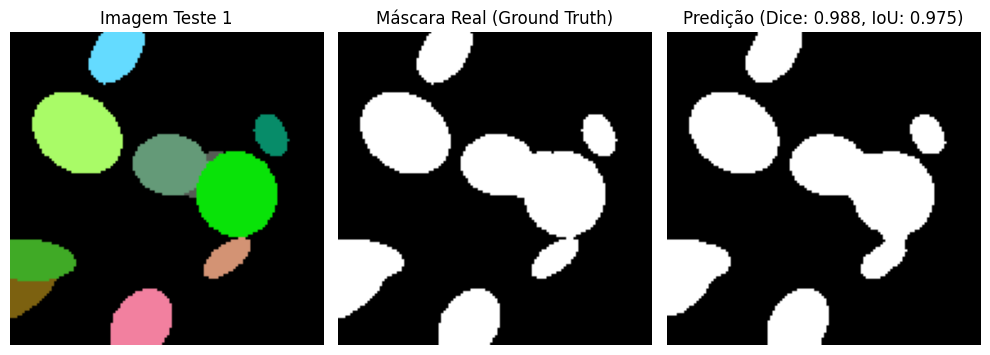

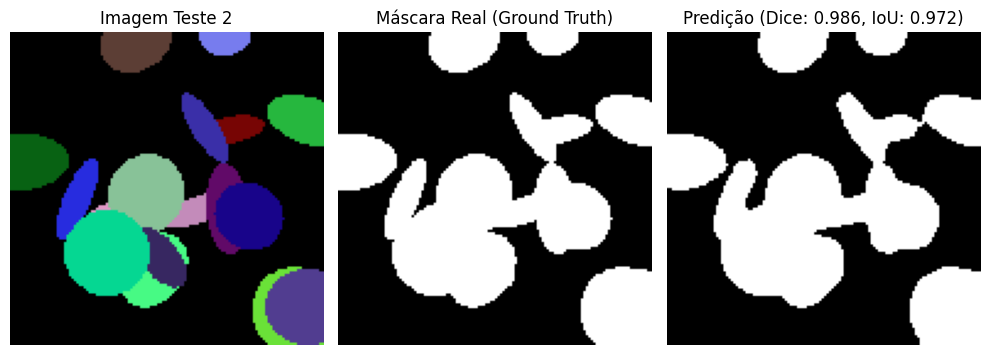

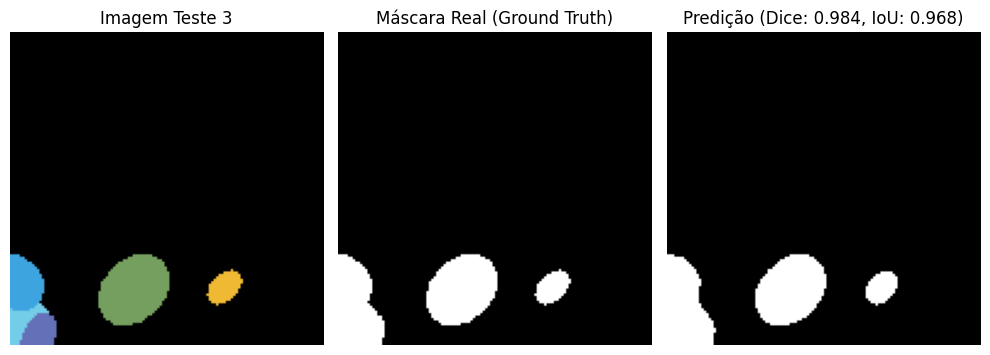

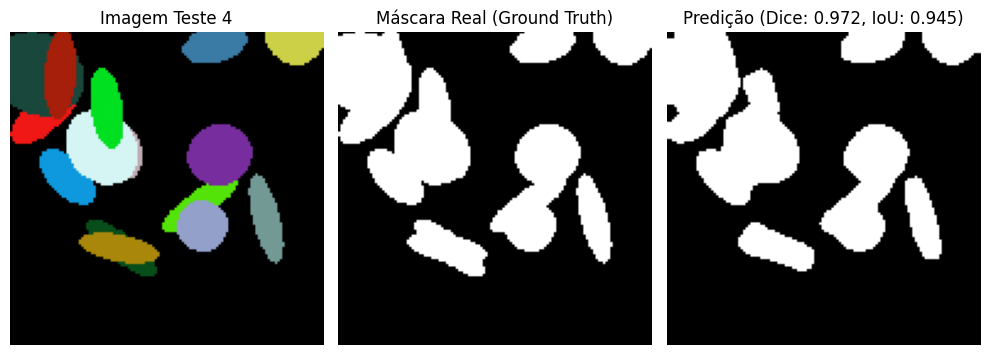

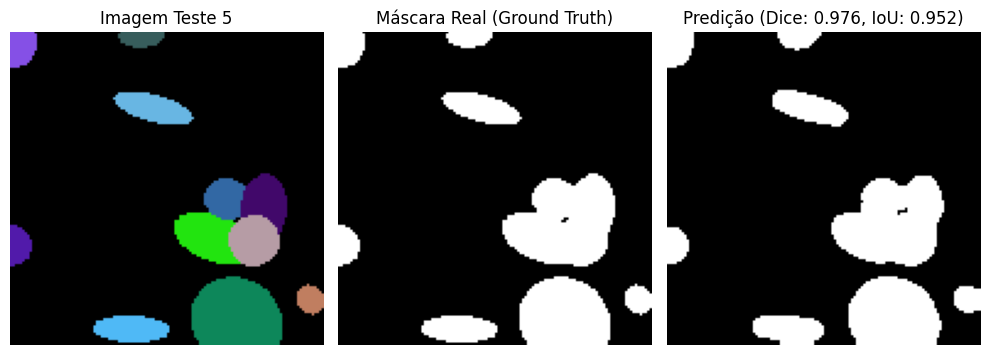

In [7]:
# 7. Visualização das Predições Binárias no Teste Sintético
utils.plot_predictions(model_synth, X_test_synth, y_test_synth, device=device, num_samples=5)


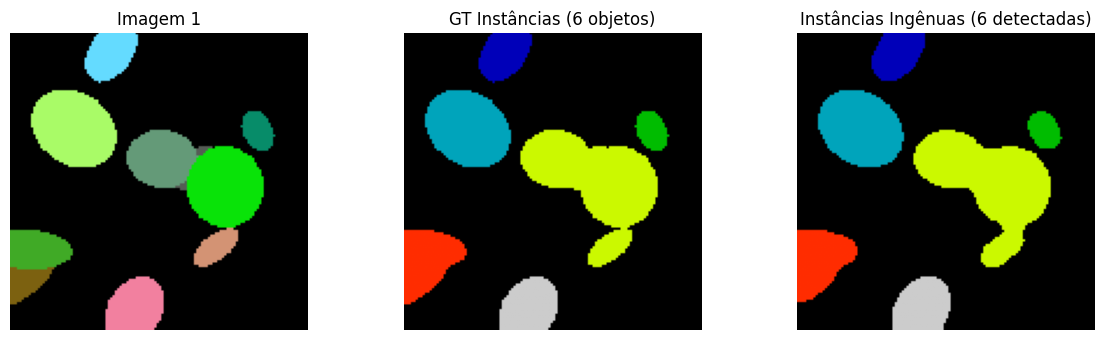

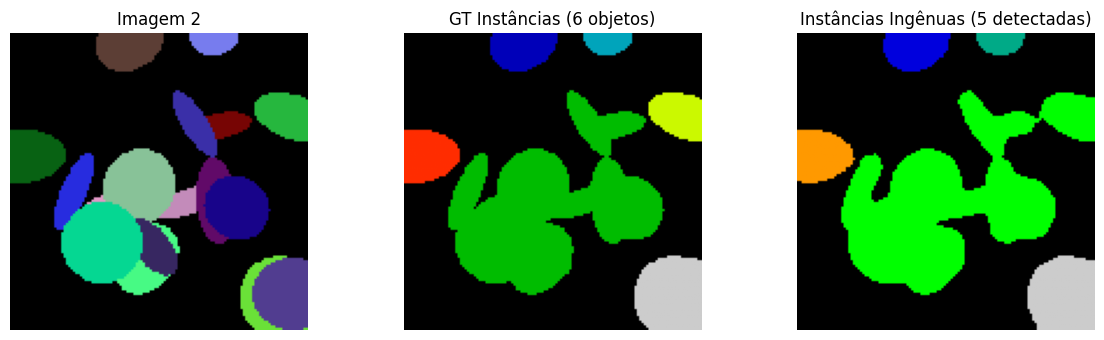

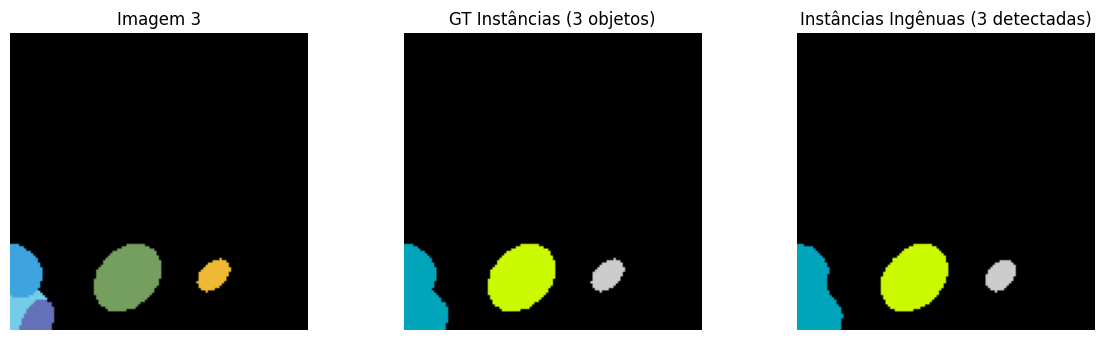

In [8]:
# 8. Extração de Instâncias pelo Método Ingênuo (Limiar + Componentes Conexos) no Dataset Sintético
utils.plot_naive_instance_extraction(model_synth, X_test_synth, y_test_synth, device=device, num_samples=3, threshold=0.5)


## Parte 1 — Segmentação e Extração de Instâncias nos Dados Reais ()
Carregamento das 670 amostras de microscopia do Data Science Bowl 2018. Múltiplas máscaras individuais de núcleos por imagem são combinadas em uma máscara de segmentação semântica binária.


In [10]:
# 9. Carregamento e Pré-processamento dos Dados Reais (DSB2018)
stage1_path = "../data/stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))

# Divisão em Treino (70%), Validação (15%) e Teste (15%)
X_train_real, y_train_real, X_val_real, y_val_real, X_test_real, y_test_real = utils.split_dataset(
    images_real, masks_real, train_ratio=0.70, val_ratio=0.15, seed=42
)

print(f"[Dados Reais] Conjunto de Treino:   X={X_train_real.shape}, y={y_train_real.shape}")
print(f"[Dados Reais] Conjunto de Validação: X={X_val_real.shape}, y={y_val_real.shape}")
print(f"[Dados Reais] Conjunto de Teste:     X={X_test_real.shape}, y={y_test_real.shape}")


Carregando 670 amostras de '../data/stage1_train'...
Dataset real carregado em 68.71 segundos!
[Dados Reais] Conjunto de Treino:   X=(468, 128, 128, 3), y=(468, 128, 128)
[Dados Reais] Conjunto de Validação: X=(101, 128, 128, 3), y=(101, 128, 128)
[Dados Reais] Conjunto de Teste:     X=(101, 128, 128, 3), y=(101, 128, 128)


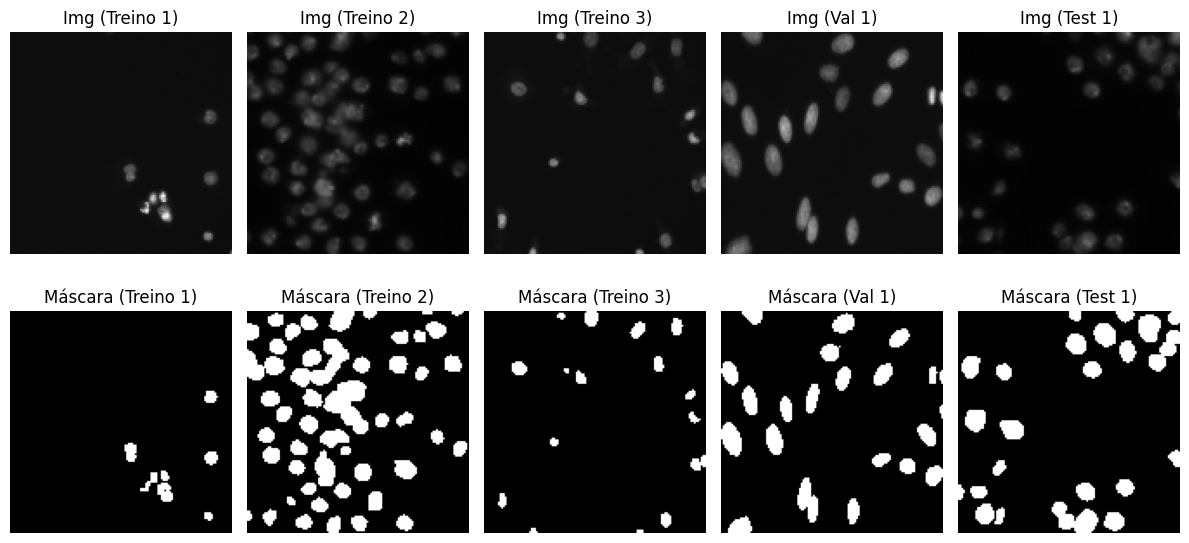

In [11]:
# 10. Visualização de Amostras do Dataset Real de Microscopia
utils.plot_dataset_samples(X_train_real, y_train_real, X_val_real, y_val_real, X_test_real, y_test_real)


In [12]:
# 11. Treinamento da U-Net nos Dados Reais
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
print("=== Treinamento no Dataset Real (stage1_train) ===")
utils.train_model(
    model=model_real,
    X_train=X_train_real,
    y_train=y_train_real,
    X_val=X_val_real,
    y_val=y_val_real,
    device=device,
    num_epochs=10,
    batch_size=16,
    learning_rate=0.001
)


=== Treinamento no Dataset Real (stage1_train) ===
Epoch [ 1/10] | Train Loss: 0.4680 | Val Loss: 0.4216
Epoch [ 2/10] | Train Loss: 0.2573 | Val Loss: 0.2123
Epoch [ 3/10] | Train Loss: 0.1839 | Val Loss: 0.1690
Epoch [ 4/10] | Train Loss: 0.1474 | Val Loss: 0.1486
Epoch [ 5/10] | Train Loss: 0.1261 | Val Loss: 0.1410
Epoch [ 6/10] | Train Loss: 0.1132 | Val Loss: 0.1431
Epoch [ 7/10] | Train Loss: 0.1034 | Val Loss: 0.1379
Epoch [ 8/10] | Train Loss: 0.0983 | Val Loss: 0.1234
Epoch [ 9/10] | Train Loss: 0.0929 | Val Loss: 0.1118
Epoch [10/10] | Train Loss: 0.0874 | Val Loss: 0.1409


In [13]:
# 12. Avaliação Quantitativa no Teste Real (Dice & IoU Semânticos)
test_dice_real, test_iou_real = utils.evaluate_model(model_real, X_test_real, y_test_real, device=device, batch_size=16)
print(f"--- Avaliação no Teste Real (X_test_real) ---")
print(f"Mean Dice Coefficient: {test_dice_real:.4f}")
print(f"Mean IoU (Jaccard Index): {test_iou_real:.4f}")


--- Avaliação no Teste Real (X_test_real) ---
Mean Dice Coefficient: 0.8330
Mean IoU (Jaccard Index): 0.7319


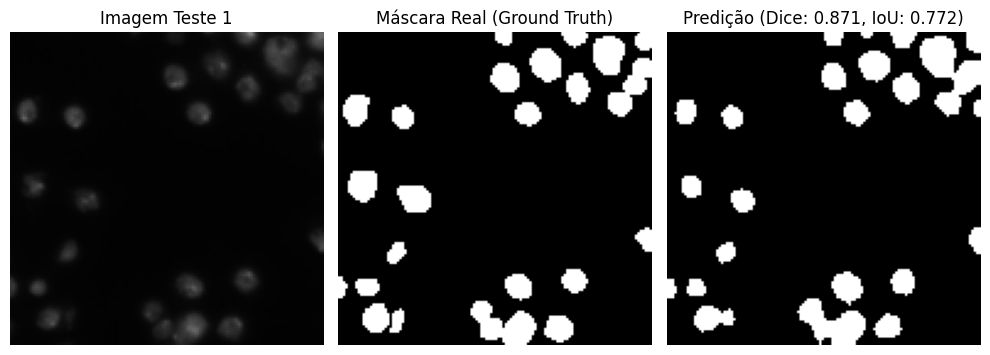

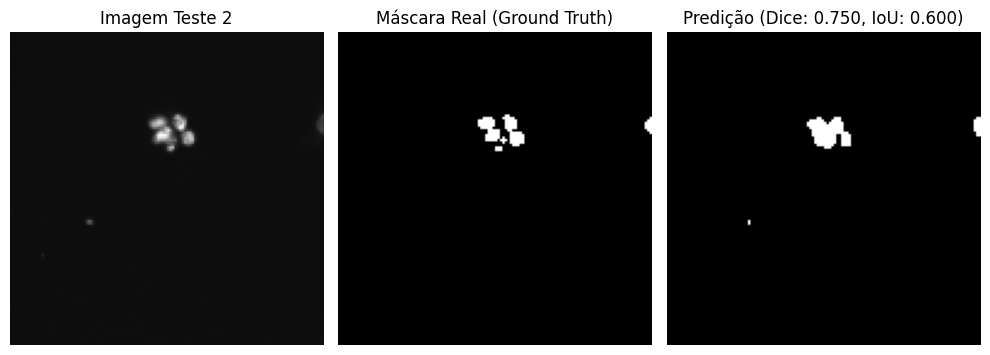

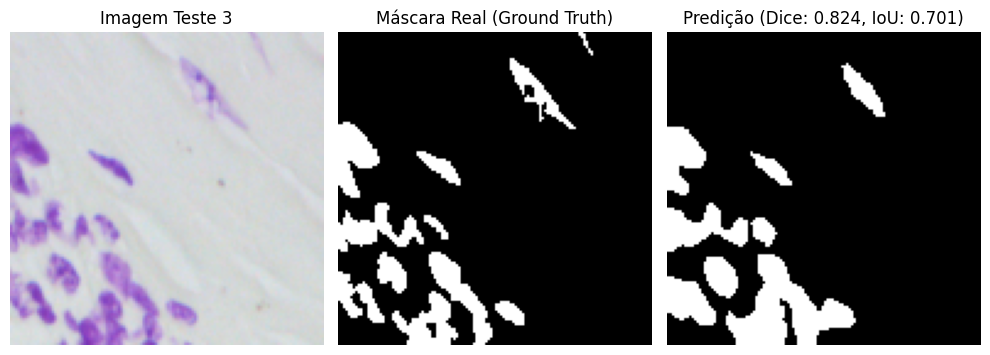

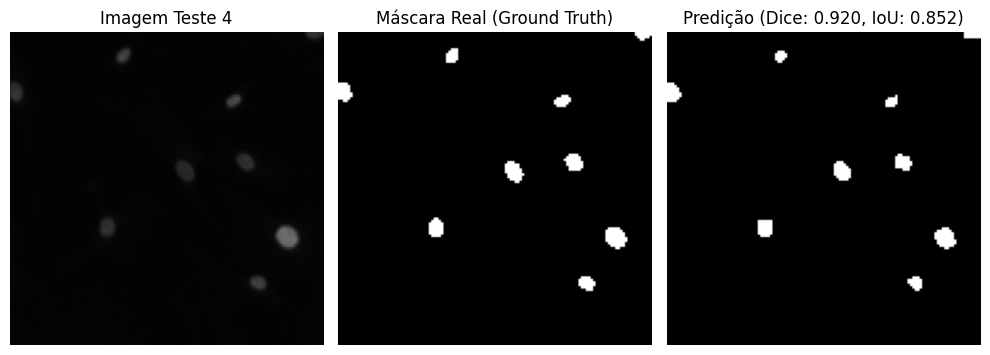

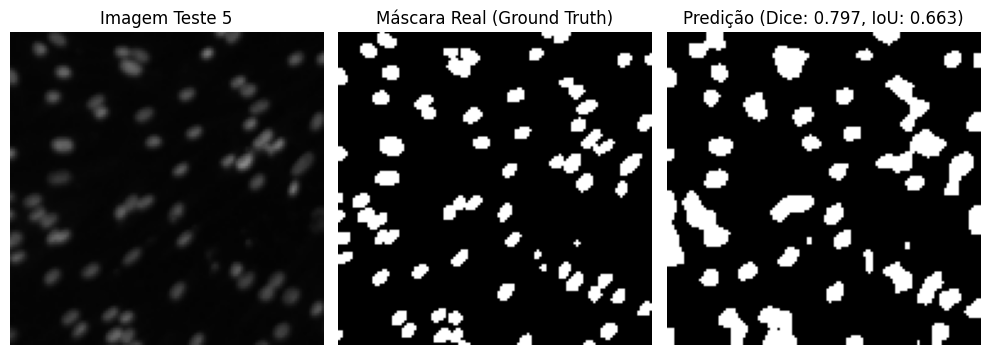

In [14]:
# 13. Visualização das Predições Binárias nas Imagens Reais de Teste
utils.plot_predictions(model_real, X_test_real, y_test_real, device=device, num_samples=5)


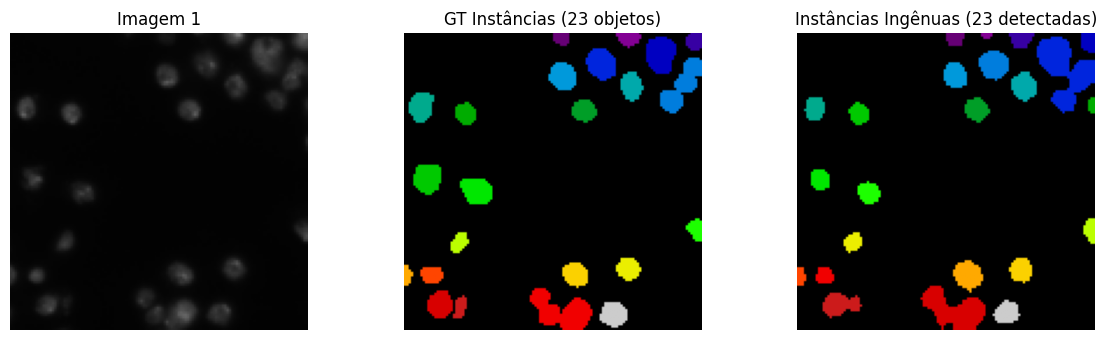

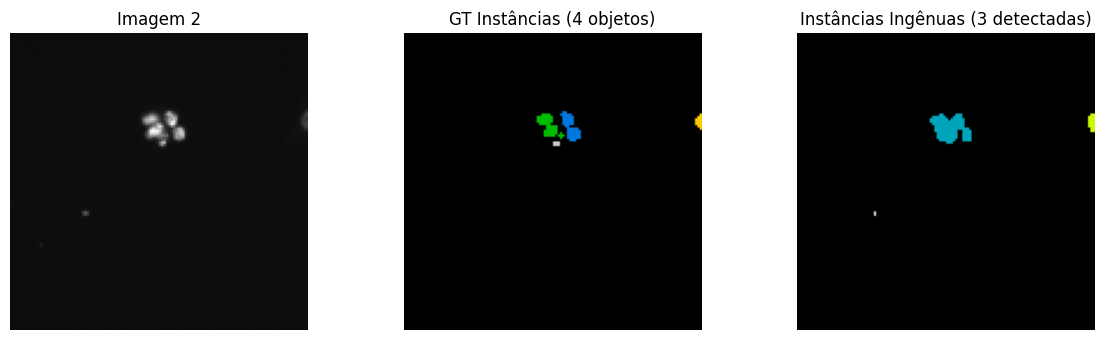

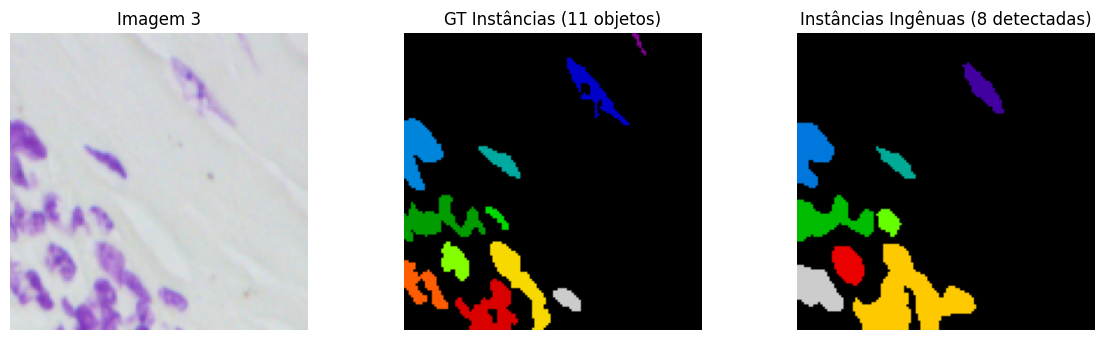

In [15]:
# 14. Extração de Instâncias pelo Método Ingênuo (Limiar + Componentes Conexos) nos Dados Reais de Microscopia
utils.plot_naive_instance_extraction(model_real, X_test_real, y_test_real, device=device, num_samples=3, threshold=0.5)
